In [1]:
import numpy as np
import os


In [2]:
DATA_PATH = "../data/raw/IRISMIL_dataset_10000_bags.npz"

data = np.load(DATA_PATH, allow_pickle=True)

X = data["data_scaled"]
mask = data["masks"]
y = data["obs_classes"]
groups = data["groups"]


MemoryError: Unable to allocate 9.83 GiB for an array with shape (2640000000,) and data type float32

In [4]:
print("Original X shape:", X.shape)
print("Original mask shape:", mask.shape)


Original X shape: (10000, 1100, 240)
Original mask shape: (10000, 1100)


In [5]:
NEW_TIMESTEPS = 400


In [6]:
def extract_last_timesteps(X, mask, timesteps=400):
    X_new = []
    mask_new = []

    for i in range(X.shape[0]):
        valid_idx = np.where(mask[i] == 1)[0]

        if len(valid_idx) >= timesteps:
            selected_idx = valid_idx[-timesteps:]
        else:
            selected_idx = valid_idx  # rare case

        x_i = X[i, selected_idx, :]
        m_i = mask[i, selected_idx]

        # pad if needed
        if x_i.shape[0] < timesteps:
            pad_len = timesteps - x_i.shape[0]
            x_i = np.pad(x_i, ((pad_len, 0), (0, 0)))
            m_i = np.pad(m_i, (pad_len, 0))

        X_new.append(x_i)
        mask_new.append(m_i)

    return np.array(X_new), np.array(mask_new)


In [7]:
if X is None:
    raise RuntimeError(
        "X is not loaded due to RAM limits.\n"
        "extract_last_timesteps requires full data.\n"
        "Run this cell on Google Colab or a high-RAM machine."
    )

X_400, mask_400 = extract_last_timesteps(X, mask, NEW_TIMESTEPS)

print("Reduced X shape:", X_400.shape)
print("Reduced mask shape:", mask_400.shape)


Reduced X shape: (10000, 400, 240)
Reduced mask shape: (10000, 400)


Valid timesteps after reduction: 400.0


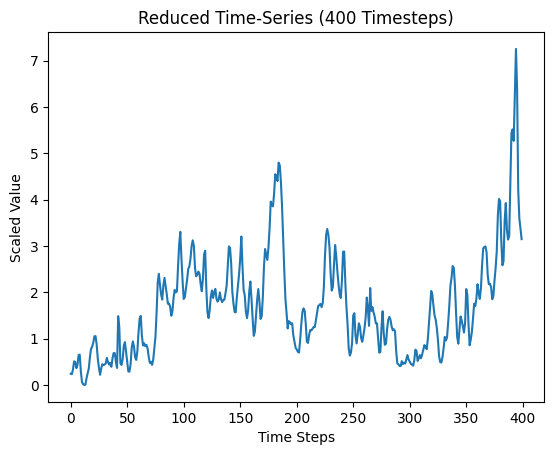

In [8]:
sample_id = 0

print("Valid timesteps after reduction:", mask_400[sample_id].sum())

import matplotlib.pyplot as plt
plt.plot(X_400[sample_id, :, 0])
plt.title("Reduced Time-Series (400 Timesteps)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Value")
plt.show()


In [9]:
import os

os.makedirs("../data/processed", exist_ok=True)


In [10]:
SAVE_PATH = "../data/processed/processed_400_timesteps.npz"   #Save Processed Data

np.savez(
    SAVE_PATH,
    X=X_400,
    mask=mask_400,
    y=y,
    groups=groups
)

print("Saved processed data to:", SAVE_PATH)


Saved processed data to: ../data/processed/processed_400_timesteps.npz
